# Get data

In [8]:
from influxdb_client import InfluxDBClient
from influxdb_client.client.write_api import SYNCHRONOUS
import pandas as pd
from pathlib import Path # Added this since Path is used at the end!

def load_and_save_from_influxdb(bucket: str):
    # Replace these with your InfluxDB token, organization, and bucket
    org = "ur3e"
    token = "SECRET_AF"

    # Initialize the client
    client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
    write_api = client.write_api(write_options=SYNCHRONOUS)   
    query_api = client.query_api()

    time_start = "-1000h"
    time_stop = "now()"

    # Get sensor data
    query_sensor_data = f'''
        from(bucket: "{bucket}")
        |> range(start: {time_start}, stop: {time_stop})
        |> filter(fn: (r) => r["_measurement"] == "robotarm.pt.state")
        |> filter(fn: (r) => r["_field"] =~ /(((q_actual|qd_actual|q_target)_[0-6])|(tcp_pose_[0-6]))/)
        |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
        '''

    df_sensor_data = query_api.query_data_frame(query_sensor_data)

    # Get wear injections
    query_wear_injections = f'''
        from(bucket: "{bucket}")
        |> range(start: {time_start}, stop: {time_stop})
        |> filter(fn: (r) => r["_measurement"] == "robotarm.ctrl")
        |> filter(fn: (r) => r["_field"] =~ /joints_0/)
        |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
        '''

    df_wear_injections = query_api.query_data_frame(query_wear_injections)

    # Remove unwanted columns
    cols_to_exclude = ["result", "table", "_start", "_stop", "_measurement", "msg_type"]
    df_filtered_sensor_data = df_sensor_data.drop(columns=cols_to_exclude, errors='ignore')
    df_filtered_wear_injections = df_wear_injections.drop(columns=["result", "table", "_start", "_stop", "_measurement", "msg_type"], errors='ignore')

    # ==== CONSTRUCT LABELED DATAFRAME ====
    
    # 1. Ensure sensor time column is a datetime object 
    df_filtered_sensor_data['_time'] = pd.to_datetime(df_filtered_sensor_data['_time'])

    # 2. Pre-initialize all 6 joint columns to 0
    # (Assuming a UR3e robot which has 6 joints: 0 through 5)
    for i in range(6):
        df_filtered_sensor_data[f'joint_{i}_worn'] = 0

    # 3. Process wear injections ONLY if they exist in this bucket
    if not df_filtered_wear_injections.empty and 'joints_0' in df_filtered_wear_injections.columns:
        
        df_filtered_wear_injections['_time'] = pd.to_datetime(df_filtered_wear_injections['_time'])

        # Extract both the timestamps AND the joint numbers into lists
        reference_timestamps = df_filtered_wear_injections['_time'].tolist()
        joint_numbers = df_filtered_wear_injections['joints_0'].tolist()

        # Reorder in terms of joint_numbers
        sorted_pairs = sorted(zip(joint_numbers, reference_timestamps))
        joint_numbers, reference_timestamps = map(list, zip(*sorted_pairs))

        # Use zip() to loop through both lists at the same time
        for ref_time, joint_num in zip(reference_timestamps, joint_numbers):
            # Cast joint_num to int just in case it came back as a float (e.g., 1.0)
            col_name = f'joint_{int(joint_num)}_worn'
            
            # Apply the binary comparison logic (Overwrites the default 0s)
            df_filtered_sensor_data[col_name] = (df_filtered_sensor_data['_time'] > ref_time).astype(int)

    # Remove timestamps for all dataframes
    df_filtered_sensor_data = df_filtered_sensor_data.drop(columns=["_time"])

    # ==== SAVE THE DATAFRAME ====

    # 1. Define the directory and create it if it doesn't exist
    output_dir = Path("./data")
    output_dir.mkdir(parents=True, exist_ok=True)

    # 2. Save the Training sets
    file_path = output_dir / f"{bucket}.csv" 
    df_filtered_sensor_data.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

    return df_filtered_sensor_data

def load_data_bucket(bucket: str) -> pd.DataFrame:
    # Check if the file already exists
    file_path = Path(f"./data/{bucket}.csv")
    if file_path.exists():
        print(f"Loading existing file: {file_path}")
        return pd.read_csv(file_path)
    else:
        print(f"File not found: {file_path}. Fetching from InfluxDB...")
        return load_and_save_from_influxdb(bucket)

In [9]:
from pathlib import Path

# Put all dataframes from InfluxDB into lists
train_dfs = []
for i in range(12):
    # try:
    train_dfs.append(load_data_bucket(f"train_data_{i}"))
    # except:
    #     print(f"Failed to fetch train_data_{i}")

test_dfs = []
for i in range(6):
    try:
        test_dfs.append(load_data_bucket(f"test_data_{i}"))
    except:
        print(f"Failed to fetch test_data_{i}")


File not found: data\train_data_0.csv. Fetching from InfluxDB...
Saved: data\train_data_0.csv
File not found: data\train_data_1.csv. Fetching from InfluxDB...
Saved: data\train_data_1.csv
File not found: data\train_data_2.csv. Fetching from InfluxDB...
Saved: data\train_data_2.csv
File not found: data\train_data_3.csv. Fetching from InfluxDB...
Saved: data\train_data_3.csv
File not found: data\train_data_4.csv. Fetching from InfluxDB...
Saved: data\train_data_4.csv
File not found: data\train_data_5.csv. Fetching from InfluxDB...
Saved: data\train_data_5.csv
File not found: data\train_data_6.csv. Fetching from InfluxDB...
Saved: data\train_data_6.csv
File not found: data\train_data_7.csv. Fetching from InfluxDB...
Saved: data\train_data_7.csv
File not found: data\train_data_8.csv. Fetching from InfluxDB...
Saved: data\train_data_8.csv
File not found: data\train_data_9.csv. Fetching from InfluxDB...
Saved: data\train_data_9.csv
File not found: data\train_data_10.csv. Fetching from Influx

# Preprocess data

In [10]:
import roboticstoolbox as rtb
import numpy as np

# Load the standard UR3e DH parameters once globally
link1 = rtb.RevoluteDH(d=0.15185, a=0.0,      alpha=np.pi / 2)
link2 = rtb.RevoluteDH(d=0.0,     a=-0.24355, alpha=0.0)
link3 = rtb.RevoluteDH(d=0.0,     a=-0.2132,  alpha=0.0)
link4 = rtb.RevoluteDH(d=0.13105, a=0.0,      alpha=np.pi / 2)
link5 = rtb.RevoluteDH(d=0.08535, a=0.0,      alpha=-np.pi / 2)
link6 = rtb.RevoluteDH(d=0.0921,  a=0.0,      alpha=0.0)
robot = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="My_UR3e")

def replace_tcp_with_deviation(df):
    """
    Calculates TCP deviation, drops raw tcp_pose columns, adds the deviation 
    as a feature, and ensures the 6 labels stay at the very end.
    """
    df_processed = df.copy()
    n_samples = len(df_processed)
    
    # 1. Extract joints and measured TCP
    q_actual = df_processed[[f'q_actual_{i}' for i in range(6)]].to_numpy()
    tcp_measured = df_processed[[f'tcp_pose_{i}' for i in range(3)]].to_numpy()
    
    # 2. Calculate Theoretical TCP using Forward Kinematics
    tcp_theoretical = np.zeros((n_samples, 3))
    for j in range(n_samples):
        tcp_theoretical[j, :] = robot.fkine(q_actual[j, :]).t
        
    # 3. Calculate the Error Magnitude (in mm)
    tcp_error_vector_mm = (tcp_theoretical - tcp_measured) * 1000
    
    # 4. Drop the old tcp_pose columns (X, Y, Z, Rx, Ry, Rz)
    cols_to_drop = [f'tcp_pose_{i}' for i in range(6)]
    # Filter to only drop columns that actually exist in the dataframe
    cols_to_drop = [c for c in cols_to_drop if c in df_processed.columns]
    df_processed = df_processed.drop(columns=cols_to_drop)
    
    # 5. Isolate feature columns and label columns
    label_cols = [c for c in df_processed.columns if 'worn' in c]
    feature_cols = [c for c in df_processed.columns if c not in label_cols]
    
    # Add the new directional features
    df_processed['tcp_dev_x_mm'] = tcp_error_vector_mm[:, 0]
    df_processed['tcp_dev_y_mm'] = tcp_error_vector_mm[:, 1]
    df_processed['tcp_dev_z_mm'] = tcp_error_vector_mm[:, 2]

    # 6. Add the new deviation feature and reorder
    df_processed['tcp_deviation_mm'] = np.linalg.norm(tcp_error_vector_mm, axis=1)
    
    # Reconstruct the dataframe: [All Features] + [TCP Deviation] + [6 Labels]
    final_columns = feature_cols + ['tcp_dev_x_mm', 'tcp_dev_y_mm', 'tcp_dev_z_mm', 'tcp_deviation_mm'] + label_cols
    
    return df_processed[final_columns]

In [11]:
def replace_joints_with_residuals(df):
    """
    Takes a dataframe, calculates joint tracking errors (target - actual),
    drops the raw actual and target columns, and returns the processed dataframe.
    """
    df_processed = df.copy()
    
    # 1. Calculate Joint Tracking Errors (Residuals)
    for i in range(6):
        # Positional Error
        df_processed[f'q_error_{i}'] = df_processed[f'q_target_{i}'] - df_processed[f'q_actual_{i}']
        
    # 2. Compile a list of all raw columns to drop
    cols_to_drop = []
    cols_to_drop += [f'q_actual_{i}' for i in range(6)]
    # cols_to_drop += [f'q_target_{i}' for i in range(6)]

    # Filter to only drop columns that actually exist in the dataframe
    cols_to_drop = [c for c in cols_to_drop if c in df_processed.columns]
    df_processed = df_processed.drop(columns=cols_to_drop)
    
    # 3. Isolate feature columns and label columns to ensure labels stay at the end
    label_cols = [c for c in df_processed.columns if 'worn' in c]
    feature_cols = [c for c in df_processed.columns if c not in label_cols]
    
    # 4. Reconstruct and return the dataframe
    final_columns = feature_cols + label_cols
    
    return df_processed[final_columns]

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Print a quick status update since FK takes a bit of time to compute
print("Calculating TCP Deviations for Training Data...")
train_dfs = [replace_joints_with_residuals(replace_tcp_with_deviation(df)) for df in train_dfs]

print("Calculating TCP Deviations for Testing Data...")
test_dfs = [replace_joints_with_residuals(replace_tcp_with_deviation(df)) for df in test_dfs]

# Now proceed with your scaling exactly as before
train_data_combined = pd.concat(train_dfs)
feature_cols = train_data_combined.columns[:-6]

# Fit scaler ONLY on the training features
scaler = StandardScaler()
scaler.fit(train_data_combined[feature_cols])

def scale_features(df):
    """Helper to scale features but leave binary targets untouched."""
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaler.transform(df[feature_cols])
    return df_scaled

# Apply to datasets
train_dfs_scaled = [scale_features(df) for df in train_dfs]
test_dfs_scaled = [scale_features(df) for df in test_dfs]

Calculating TCP Deviations for Training Data...
Calculating TCP Deviations for Testing Data...


In [13]:
import torch
from torch.utils.data import Dataset
import numpy as np

class MultiSeriesDataset(Dataset):
    def __init__(self, dataframes, seq_length):
        """
        Args:
            dataframes (list of pd.DataFrame): List of independent time-series dataframes.
            seq_length (int): How many past time steps to use as input (X).
        """
        self.seq_length = seq_length
        
        # We convert once to PyTorch tensors and keep them in a list.
        # No sliding windows are created here, saving massive amounts of RAM.
        self.data = [torch.tensor(df.values, dtype=torch.float32) for df in dataframes]
        
        # Instead of storing GBs of overlapping floats, we store a tiny list of tuples:
        # (dataframe_index, window_start_index)
        self.index_map = []
        
        for df_idx, series in enumerate(self.data):
            # Calculate how many valid windows can be pulled from this dataframe
            num_windows = len(series) - self.seq_length
            
            if num_windows > 0:
                # Store the coordinates to fetch the window later
                for start_idx in range(0, num_windows, 3 * self.seq_length // 2):
                    self.index_map.append((df_idx, start_idx))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        # 3. Generate the window ON THE FLY
        df_idx, start_idx = self.index_map[idx]
        
        # Fetch the specific dataframe tensor
        series = self.data[df_idx]
        
        # Slice X: The sequence of past observations (excluding last 6 columns)
        window_x = series[start_idx : start_idx + self.seq_length, :-6]
        
        # Slice y: The target values at the next time step (the last 6 columns)
        window_y = series[start_idx : start_idx + self.seq_length, -6:]

        return window_x, window_y

In [14]:

# Declare datasets
train_ds = MultiSeriesDataset(train_dfs_scaled, 100)
test_ds = MultiSeriesDataset(test_dfs_scaled, 100)

#SLET MIG
# temp_train_dfs = [df.iloc[:13000] for df in train_dfs_scaled]
# temp_test_dfs = [df.iloc[:13000] for df in test_dfs_scaled]
# train_ds = MultiSeriesDataset(temp_train_dfs, 100)
# test_ds = MultiSeriesDataset(temp_test_dfs, 100)

# Declare dataloaders
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=512, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=512, shuffle=False)

In [15]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, input_size=22, hidden_size=64, num_layers=1, output_size=6):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True
        )
        
        # ADD THIS: Drops 40% of the connections randomly during training
        self.dropout = nn.Dropout(p=0.4) 
        
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # ADD THIS: Apply dropout before the final prediction
        lstm_out = self.dropout(lstm_out)
        
        prediction = self.fc(lstm_out)
        return prediction

In [16]:
import torch

# 1. Define the device (automatically falls back to CPU if no GPU is found)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(model, train_loader, optim, loss_fn):
    model.train()
    running_loss = 0
    total_predictions = 0
    
    for x, y in train_loader:
        # 2. Move data to the device
        x, y = x.to(device), y.to(device)
        
        # Reset gradients
        optim.zero_grad()
        # Make prediction by model
        pred = model(x)
        # Calc loss gradient
        loss = loss_fn(pred, y)
        loss.backward()
        # Optimize model
        optim.step()

        # Gather loss
        running_loss += loss.item() * x.size(0) 
        total_predictions += x.size(0) # Count samples, not total elements
        
    mean_loss = running_loss / total_predictions if total_predictions > 0 else 0
    return mean_loss

def test(model, test_loader, loss_fn):
    model.eval()
    running_loss = 0
    
    correct_predictions = 0
    correct_joint_predictions = torch.zeros((6), device=device)
    correct_indications = 0
    correct_joint_indications = torch.zeros((6), device=device)
    
    total_timesteps = 0  # Used for accuracy
    total_elements = 0   # Used to keep your loss calculation consistent
    
    with torch.no_grad():
        for x, y in test_loader:
            # 2. Move data to the device
            x, y = x.to(device), y.to(device)
            
            pred = model(x)
            loss = loss_fn(pred, y)

            # Accuracy calculation
            pred_labels = (pred > 0).float() # same as nn.functional.sigmoid(pred) > 0.5
            
            # .all(dim=-1) checks the last dimension (the 6 joints). 
            # It returns True ONLY if all 6 predictions match the targets for that timestep.
            correct_at_timestep = (pred_labels == y)
            correct_indication_at_timestep = (pred_labels >= y)
            correct_at_timestep_global = correct_at_timestep.all(dim=-1)
            correct_indication_at_timestep_global = correct_indication_at_timestep.all(dim=-1)
            
            # Sum up the fully correct timesteps
            correct_predictions += correct_at_timestep_global.sum().item()
            correct_indications += correct_indication_at_timestep_global.sum().item()
            correct_joint_predictions += correct_at_timestep.sum(dim=(0, 1))
            correct_joint_indications += correct_indication_at_timestep.sum(dim=(0, 1))
            
            # Count total number of timesteps evaluated (batch_size * sequence_length)
            total_timesteps += correct_at_timestep_global.numel()

            # Update loss
            running_loss += loss.item() * x.size(0)
            total_elements += x.size(0) 
            
        # Calculate overall accuracy based on exact-match timesteps
        accuracy = correct_predictions / total_timesteps if total_timesteps > 0 else 0
        joint_accuracies = correct_joint_predictions / total_timesteps if total_timesteps > 0 else 0

        # Calculate overall indication accuracy
        indication_accuracy = correct_indications / total_timesteps if total_timesteps > 0 else 0
        joint_indication_accuracies = correct_joint_indications / total_timesteps if total_timesteps > 0 else 0
        
        # Calculate loss exactly as you had it before
        mean_loss = running_loss / total_elements if total_elements > 0 else 0
        
    return mean_loss, accuracy, joint_accuracies, indication_accuracy, joint_indication_accuracies

In [17]:
class CustomLoss(nn.Module):
    def __init__(self, seq_length=100, steepness=2.0):
        super().__init__()
        # CRITICAL FIX: Tell PyTorch NOT to average the loss yet
        class_weights = torch.full([6], 4).to(device)
        self.bce_loss = nn.BCEWithLogitsLoss(reduction='none', pos_weight=class_weights) 

        t = torch.linspace(0, 1, seq_length)
        mask_1d = (torch.exp(steepness * t) - 1) / (torch.exp(torch.tensor(steepness)) - 1)
        mask_3d = mask_1d.view(1, seq_length, 1)
        self.register_buffer('mask', mask_3d)

    def forward(self, pred, y):
        # Now unreduced_loss correctly has shape: [batch_size, seq_length, 6]
        unreduced_loss = self.bce_loss(pred, y)
        
        # Now the mask correctly scales the specific timesteps
        masked_loss = unreduced_loss * self.mask
        
        return masked_loss.mean()

In [25]:
# Prepare for training
import torch
model = Net(hidden_size=64, num_layers=1).to(device)
optimizer = torch.optim.AdamW(params=model.parameters(), lr=0.001, weight_decay=0.01)
loss_fn = CustomLoss().to(device) # nn.BCEWithLogitsLoss() 

train_loss, test_loss, test_accuracies, test_joint_accuracies, test_indication_accuracies, test_joint_indication_accuracies = [], [], [], [], [], []

In [26]:
# Train
epochs = 200
for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    trl = train(model, train_loader, optimizer, loss_fn)
    train_loss.append(trl)
    tel, test_accuracy, test_joint_accuracy, test_indication_accuracy, test_joint_indication_accuracy = test(model, test_loader, loss_fn)
    test_loss.append(tel)
    test_accuracies.append(test_accuracy)
    test_joint_accuracies.append(test_joint_accuracy)
    test_indication_accuracies.append(test_indication_accuracy)
    test_joint_indication_accuracies.append(test_joint_indication_accuracy)

Epoch 1/200
Epoch 2/200
Epoch 3/200
Epoch 4/200
Epoch 5/200
Epoch 6/200
Epoch 7/200
Epoch 8/200
Epoch 9/200
Epoch 10/200
Epoch 11/200
Epoch 12/200
Epoch 13/200
Epoch 14/200
Epoch 15/200
Epoch 16/200
Epoch 17/200
Epoch 18/200
Epoch 19/200
Epoch 20/200
Epoch 21/200
Epoch 22/200
Epoch 23/200
Epoch 24/200
Epoch 25/200
Epoch 26/200
Epoch 27/200
Epoch 28/200
Epoch 29/200
Epoch 30/200
Epoch 31/200
Epoch 32/200
Epoch 33/200
Epoch 34/200
Epoch 35/200
Epoch 36/200
Epoch 37/200
Epoch 38/200
Epoch 39/200
Epoch 40/200
Epoch 41/200
Epoch 42/200
Epoch 43/200
Epoch 44/200
Epoch 45/200
Epoch 46/200
Epoch 47/200
Epoch 48/200
Epoch 49/200
Epoch 50/200
Epoch 51/200
Epoch 52/200
Epoch 53/200
Epoch 54/200
Epoch 55/200
Epoch 56/200
Epoch 57/200
Epoch 58/200
Epoch 59/200
Epoch 60/200
Epoch 61/200
Epoch 62/200
Epoch 63/200
Epoch 64/200
Epoch 65/200
Epoch 66/200
Epoch 67/200
Epoch 68/200
Epoch 69/200
Epoch 70/200
Epoch 71/200
Epoch 72/200
Epoch 73/200
Epoch 74/200
Epoch 75/200
Epoch 76/200
Epoch 77/200
Epoch 78

tensor([0.7273, 0.6583, 0.7871, 0.8548, 0.7082, 0.6754], device='cuda:0')
Final test accuracy: 0.2864
Final test indication accuracy: 0.7756


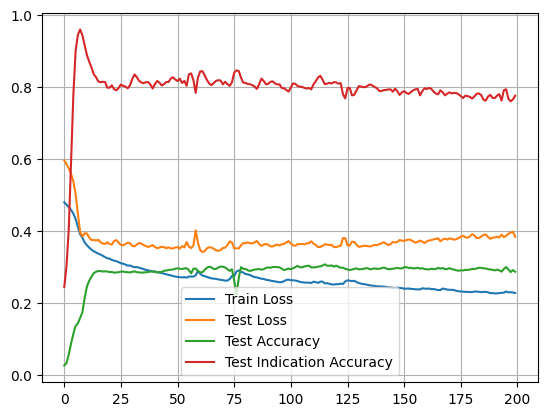

In [27]:
import matplotlib.pyplot as plt

plt.plot(np.array(train_loss), label="Train Loss")
plt.plot(np.array(test_loss), label="Test Loss")
plt.plot(test_accuracies, label="Test Accuracy")
plt.plot(test_indication_accuracies, label="Test Indication Accuracy")
plt.grid()
plt.legend()
plt.style.use('default')

print(test_joint_accuracies[-1])
print(f"Final test accuracy: {test_accuracies[-1]}")
print(f"Final test indication accuracy: {test_indication_accuracies[-1]}")

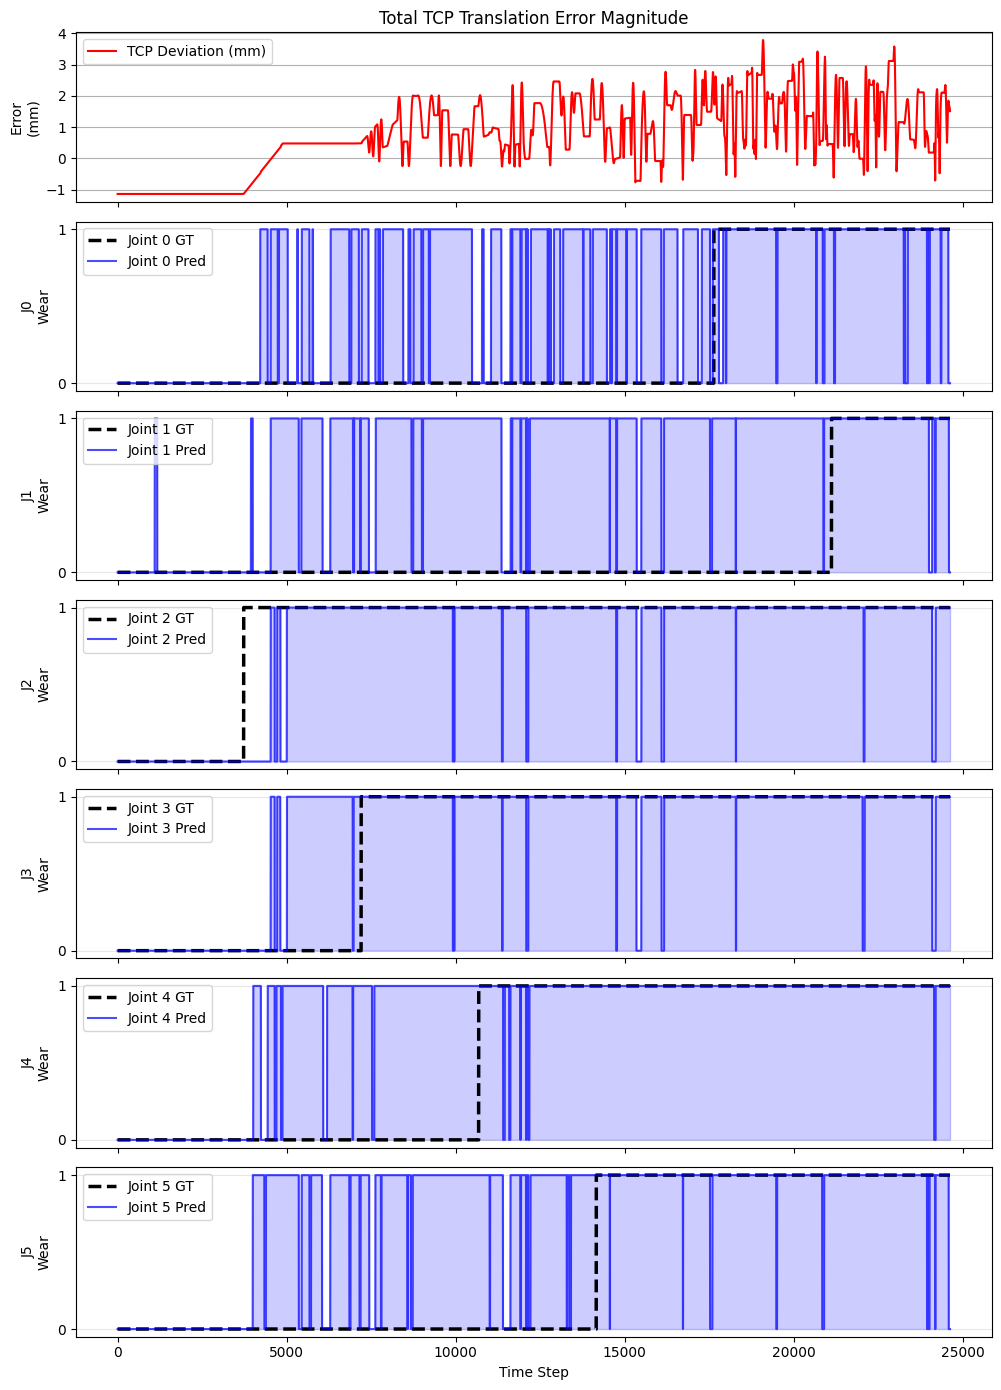

In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt

illustration_df = test_dfs_scaled[2]

# 1. Prepare tensor data
seq_length = 100
tensor_data = torch.tensor(illustration_df.to_numpy()[:, :-6]).float()

# 2. Create overlapping windows with stride=1 using unfold
windows = tensor_data.unfold(0, seq_length, 1).transpose(1, 2)

model.eval()
preds = []
batch_size = 512

with torch.no_grad():
    # 3. Process the windows in chunks
    for i in range(0, len(windows), batch_size):
        batch = windows[i:i+batch_size].to(device)
        out = model(batch)
        preds.append(out.cpu())

# Concatenate all batches
p = torch.cat(preds, dim=0)

# 4. FIX THE DIMENSIONS HERE
# If your model outputs [batch_size, seq_length, 6], extract the last timestep
if p.ndim == 3:
    p = p[:, -1, :]  # Now it is shape [batch_size, 6]

# Apply sigmoid and round
model_output = torch.sigmoid(p).numpy()
model_output_rounded = (model_output > 0.5).astype(np.float32)

# 5. Align ground truth arrays by trimming the un-windowed steps
tcp_error_mm = illustration_df["tcp_deviation_mm"].to_numpy()[seq_length-1:]

joint_worn = np.zeros((len(illustration_df) - seq_length + 1, 6))
for i in range(6):
    joint_worn[:, i] = illustration_df[f"joint_{i}_worn"].to_numpy()[seq_length-1:]

# --- Plotting ---
N = model_output_rounded.shape[0]
x_values = np.arange(N)

# Back to 7 subplots: TCP + 6 Joints (GT and Pred shared)
fig, axes = plt.subplots(7, 1, figsize=(10, 14), sharex=True)

# Subplot 0: Total TCP Error
axes[0].plot(tcp_error_mm, label="TCP Deviation (mm)", color="red")
axes[0].set_title("Total TCP Translation Error Magnitude")
axes[0].set_ylabel("Error\n(mm)")
axes[0].grid(axis="y")
axes[0].legend(loc="upper left")

# Subplots 1-6: Joint Wear Predictions vs Ground Truth
for i in range(6):
    ax = axes[i + 1]
    
    # Plot Ground Truth
    ax.plot(joint_worn[:, i], label=f"Joint {i} GT", color="black", linestyle="--", linewidth=2.5)
    
    # Plot Prediction 
    ax.plot(model_output_rounded[:, i], label=f"Joint {i} Pred", color="blue", linewidth=1.5, alpha=0.7)

    # Plot Translucent Blue Fill under prediction graph
    ax.fill_between(x_values, 0, model_output_rounded[:, i],
                        color="blue", alpha=0.2)
    
    ax.set_ylabel(f"J{i}\nWear")
    ax.set_yticks([0, 1])
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="upper left")

# Set x-label only on the bottom plot
axes[-1].set_xlabel("Time Step")

plt.tight_layout()
plt.show()

In [36]:
# Save the trained model
torch.save(model.state_dict(), "wear_localization_model_TCP_Deviation_XYZ.pth")

In [37]:
# Load the saved model 
# model = Net()
# model.load_state_dict(torch.load("wear_localization_model.pth"))

In [38]:
# Final model evaluation
test(model, train_loader, loss_fn), test(model, test_loader, loss_fn)

((0.22277504399987016,
  0.3386285362853629,
  tensor([0.7993, 0.7064, 0.8346, 0.8690, 0.6928, 0.6757], device='cuda:0'),
  0.9091881918819188,
  tensor([0.9817, 0.9621, 0.9845, 0.9891, 0.9853, 0.9874], device='cuda:0')),
 (0.3832373685836792,
  0.2864,
  tensor([0.7273, 0.6583, 0.7871, 0.8548, 0.7082, 0.6754], device='cuda:0'),
  0.7756,
  tensor([0.9147, 0.8962, 0.9363, 0.9566, 0.9620, 0.9462], device='cuda:0')))

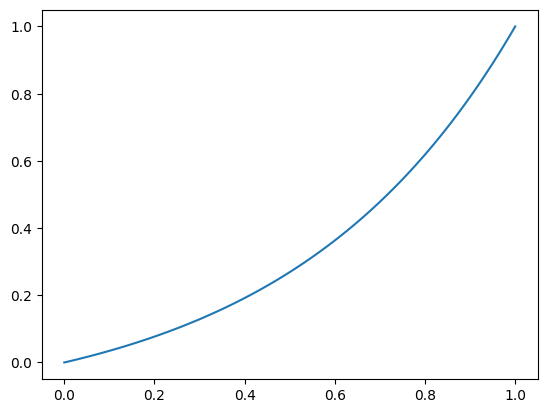

In [39]:
s = 2

xxxxx = np.linspace(0, 1, 100)
yyyy = (np.exp(s*xxxxx)-1)/(np.exp(s)-1)

plt.plot(xxxxx, yyyy)

In [ ]:
import mstlo_python as mstlo
  
# Parse formula using the DSL syntax
phi = mstlo.parse_formula("G[0, 4](a < 2)")

# Create a monitor using the selected semantics
monitor = mstlo.Monitor(phi, semantics="Rosi")

# Update the monitor with streaming data (signal_name, value, timestamp)
output = monitor.update("a", 1.0, 0.5)

# Print formatted verdicts or extract structured data
print(f"Verdicts: {output.verdicts()}")
# Verdicts: [(0.5, (-inf, 1.0))] # (timestamp, (lower_bound, upper_bound) for robustness)
output = monitor.update("a", 3.0, 1.2)
print(f"Verdicts: {output.verdicts()}")
# Verdicts: [(0.5, (-inf, -1.0)), (1.2, (-inf, -1.0))] # early indication of violation

Verdicts: [(0.5, (-inf, 1.0))]
Verdicts: [(0.5, (-inf, -1.0)), (1.2, (-inf, -1.0))]


In [7]:
import mstlo_python as mstlo

# Parse formula using the DSL syntax
phi = mstlo.parse_formula("G[0, 10](x > 5)")

# Create a monitor using the selected semantics
monitor = mstlo.Monitor(phi, semantics="Rosi")

# Update the monitor with streaming data (signal_name, value, timestamp)
output = monitor.update("x", 6.0, 0.5)

# Print formatted verdicts or extract structured data
print(f"Verdicts: {output.verdicts()}")
# Verdicts: [(0.5, (-inf, 1.0))] # (timestamp, (lower_bound, upper_bound) for robustness)
output = monitor.update("x", 3.0, 1.2)
print(f"Verdicts: {output.verdicts()}")
# Verdicts: [(0.5, (-inf, -2.0)), (1.2, (-inf, -2.0))] # early indication of violation

Verdicts: [(0.5, (-inf, 1.0))]
Verdicts: [(0.5, (-inf, -2.0)), (1.2, (-inf, -2.0))]
